In [10]:
# IT22259752 - Logistic Regression & Preprocessing Lead
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported!')

Libraries imported!


In [11]:
# Dataset loading
df = pd.read_csv('../data/StudentPerformanceFactors.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Shape: (6607, 20)
Rows: 6607, Columns: 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Target Distribution:
Performance
Medium    4573
High      1083
Low        951
Name: count, dtype: int64


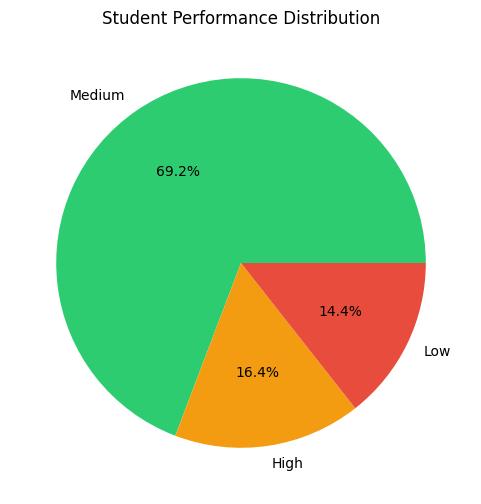

In [12]:
# Target variable - High / Medium / Low
bins = [0, 63, 70, 101]
labels = ['Low', 'Medium', 'High']
df['Performance'] = pd.cut(df['Exam_Score'], bins=bins, labels=labels)

print('Target Distribution:')
print(df['Performance'].value_counts())

# Pie chart
plt.figure(figsize=(6,6))
df['Performance'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#2ecc71','#f39c12','#e74c3c']
)
plt.title('Student Performance Distribution')
plt.ylabel('')
plt.show()

In [13]:
# Missing values check
print('Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Mode fill
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

print(' Missing values filled!')
print('Remaining:', df.isnull().sum().sum())

Missing Values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64
 Missing values filled!
Remaining: 235


In [14]:
# Label Encoding
cat_cols = [
    'Parental_Involvement', 'Access_to_Resources',
    'Extracurricular_Activities', 'Motivation_Level',
    'Internet_Access', 'Family_Income', 'Teacher_Quality',
    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(' Encoding done!')
df.head()

 Encoding done!


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance
0,23,84,1,0,0,7,73,1,1,0,...,2,1,2,3,0,1,2,1,67,Medium
1,19,64,1,2,0,8,59,1,1,2,...,2,1,0,4,0,0,1,0,61,Low
2,24,98,2,2,1,7,91,2,1,2,...,2,1,1,4,0,2,2,1,74,High
3,29,89,1,2,1,8,98,2,1,1,...,2,1,0,4,0,1,1,1,71,High
4,19,92,2,2,1,6,65,2,1,3,...,0,1,1,4,0,0,2,0,70,Medium


In [15]:
# Features & Target
X = df.drop(['Exam_Score', 'Performance'], axis=1)
y = df['Performance']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test : {X_test.shape[0]} samples')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(' Scaling done!')

Train: 5285 samples
Test : 1322 samples
 Scaling done!


In [16]:
# Model train
model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Results
acc = accuracy_score(y_test, y_pred)
print(f' Accuracy: {acc*100:.2f}%')
print()
print(classification_report(y_test, y_pred))

 Accuracy: 87.07%

              precision    recall  f1-score   support

        High       0.82      0.69      0.75       217
         Low       0.82      0.79      0.80       190
      Medium       0.89      0.93      0.91       915

    accuracy                           0.87      1322
   macro avg       0.84      0.80      0.82      1322
weighted avg       0.87      0.87      0.87      1322



<Figure size 700x500 with 0 Axes>

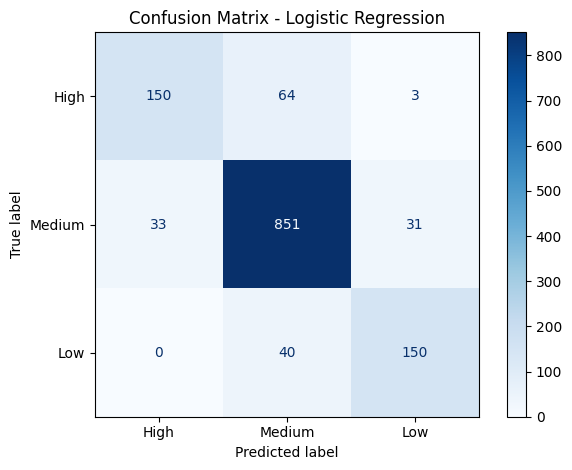

  IT22259752 - Logistic Regression Summary
  Accuracy : 87.07%
  Classes  : High / Medium / Low


In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['High', 'Medium', 'Low'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High','Medium','Low'])

plt.figure(figsize=(7,5))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

print('='*45)
print('  IT22259752 - Logistic Regression Summary')
print('='*45)
print(f'  Accuracy : {acc*100:.2f}%')
print(f'  Classes  : High / Medium / Low')
print('='*45)